Here we introduce several options for plotting and analyzing an energy landscape obtained from an AMS calculation.

In particular, `plot_energy_landscape()` can display molecular structures on top of the landscape by using two different molecule-plotting backends: `view` and `plot_molecule`. In this notebook we show how to use both approaches, how to compare layout options, and how to control the orientation of all molecules or only selected states.

A useful practical difference between the two backends is that `plot_molecule` uses explicit Euler-like rotation strings such as `"90x,0y,0z"`, while `view` specifies the viewing direction through `ViewConfig`, for example with `direction`, `normal`, and `normal_basis`. Depending on whether you want direct angle-based control or a view-oriented description, one backend may be more convenient than the other.


## Imports

This cell imports PLAMS, the energy-landscape plotting tools, the `ViewConfig` helper used by the `view` backend, and Matplotlib for figure creation.


In [1]:
import scm.plams as plams
from scm.plams.tools.plot import plot_molecule, plot_energy_landscape
from scm.plams.tools.view import ViewConfig
import matplotlib.pyplot as plt

## Build the molecular system

This cell defines the small HCNO molecule used throughout the example and guesses its bonds so that the different visualization backends can draw it properly.


In [2]:
molecule = plams.Molecule()
molecule.add_atom(plams.Atom(symbol="H", coords=(0.26799604, 1.56164318, 0.80172174)))
molecule.add_atom(plams.Atom(symbol="O", coords=(0.70317302, 1.15034441, 0.02980438)))
molecule.add_atom(plams.Atom(symbol="N", coords=(0.07385403, -1.26509181, -0.02723174)))
molecule.add_atom(plams.Atom(symbol="C", coords=(0.33895691, -0.13354579, 0.04083563)))

molecule.guess_bonds()

## Preview the molecule with `view`

This cell displays the molecule with the `view` interface. This is the first of the two backends that can also be used later inside the energy-landscape plot.


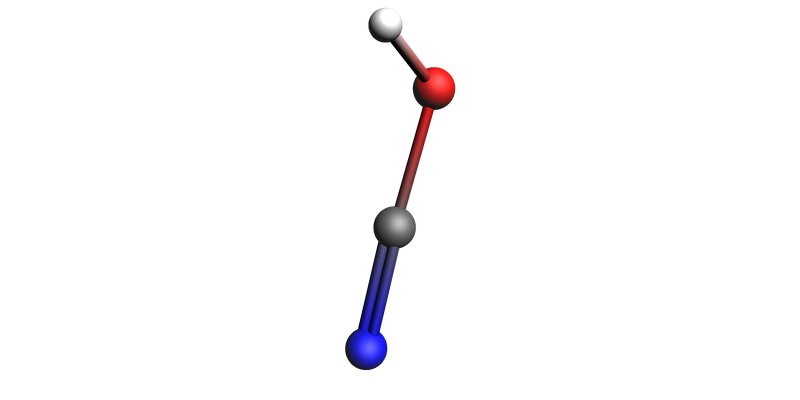

In [3]:
plams.view(molecule)

## Preview the molecule with `plot_molecule`

This cell displays the same molecule with `plot_molecule`, which is the second backend supported in the landscape examples below.


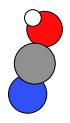

In [4]:
plot_molecule(molecule);

## PES exploration settings

This cell prepares the AMS settings used to generate the energy landscape. The setup follows the same HCNO PES exploration used in the related plotting tests.


In [5]:
settings = plams.Settings()
settings.input.ams.UseSymmetry = "No"
settings.input.ams.Task = "PESExploration"
settings.input.ams.PESExploration.RandomSeed = 1
settings.input.ams.PESExploration.Job = "ProcessSearch"
settings.input.ams.PESExploration.NumExpeditions = 500
settings.input.ams.PESExploration.NumExplorers = 4
settings.input.ams.PESExploration.SaddleSearch.MaxEnergy = 6.0
settings.input.ams.PESExploration.SaddleSearch.MinEnergyBarrier = 0.1
settings.input.ams.PESExploration.StructureComparison.UseCovalent = "Yes"
settings.input.MOPAC.Model = "AM1"

## Run/Load a precomputed landscape

This cell presents two options: rerunning the AMS job or reusing previously generated results. If the `job.run()` line is active, the notebook will perform the calculation. However, by commenting out `job.run()` and uncommenting the subsequent line, the notebook will load an existing RKF file and extract the energy landscape object.

In [6]:
job = plams.AMSJob(name="HCNO", molecule=molecule, settings=settings)

# job.run()
job = plams.AMSJob.load_external("plams_workdir/HCNO/ams.rkf")

energy_landscape = job.results.get_energy_landscape()
print(energy_landscape)

All stationary points:
State 1: CHNO local minimum @ -0.02420235 Hartree (found 1 times, results on State1_MIN)
State 2: CHNO local minimum @ -0.00530947 Hartree (found 1 times, results on State2_MIN)
State 3: CHNO local minimum @ 0.06366600 Hartree (found 1 times, results on State3_MIN)
State 4: CHNO local minimum @ 0.08915027 Hartree (found 2 times, results on State4_MIN)
State 5: CHNO local minimum @ 0.12945368 Hartree (found 1 times, results on State5_MIN)
State 6: CHNO transition state @ 0.14087766 Hartree (found 105 times, results on State6_TS_1-5)
  +- Reactants: State 1: CHNO local minimum @ -0.02420235 Hartree (found 1 times, results on State1_MIN)
     Products:  State 5: CHNO local minimum @ 0.12945368 Hartree (found 1 times, results on State5_MIN)
     Prefactors: 1.193E+13:1.542E+13 s^-1
     Barriers: 4.492:0.311 eV
State 7: CHNO transition state @ 0.16456046 Hartree (found 80 times, results on State7_TS_3-5)
  +- Reactants: State 3: CHNO local minimum @ 0.06366600 Hartre

## Default energy-landscape plot

This cell produces the basic landscape plot with the default layout and without molecule thumbnails, which is a good starting point for understanding the connectivity between states.


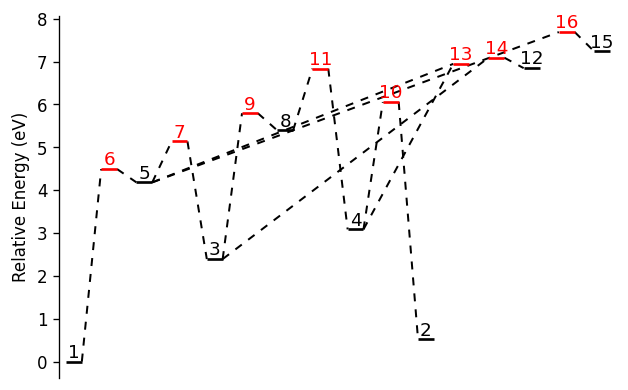

In [7]:
fig, ax = plt.subplots(dpi=120)
ax = plot_energy_landscape(energy_landscape, ax=ax)
ax;

## Change the layout

This cell redraws the same landscape with the `bfs` layout so you can compare how the ordering of states changes while keeping the same data.


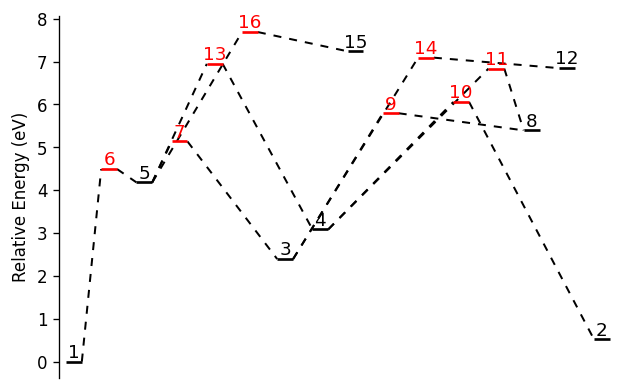

In [8]:
fig, ax = plt.subplots(dpi=120)
ax = plot_energy_landscape(energy_landscape, ax=ax, layout="bfs")
ax;

## Show molecules with the `view` backend

This cell adds molecule thumbnails above the states while using `molecule_plot_backend="view"`. This backend is convenient when you want to control the visualization through `ViewConfig` or other `view()` options, that is, by specifying the viewing direction rather than explicit Euler angles.


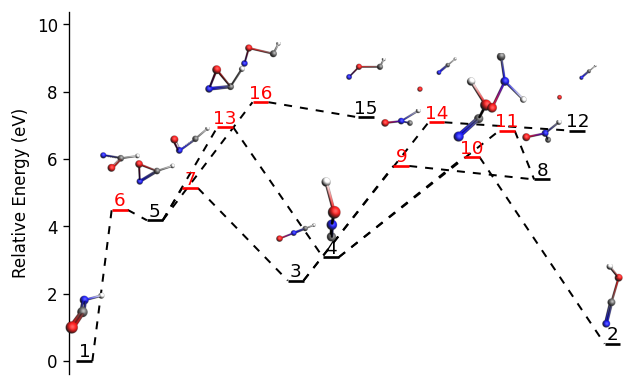

In [9]:
fig, ax = plt.subplots(dpi=120)
plot_energy_landscape(
    energy_landscape,
    ax=ax,
    layout="bfs",
    show_molecules=True,
    molecule_plot_backend="view",
)
ax;

## Show molecules with the `plot_molecule` backend

This cell displays the same landscape but uses `molecule_plot_backend="plot_molecule"`. This backend is convenient when you want simple ASE-style options such as explicit `rotation` strings, so it is often the most direct choice for angle-based orientation control.


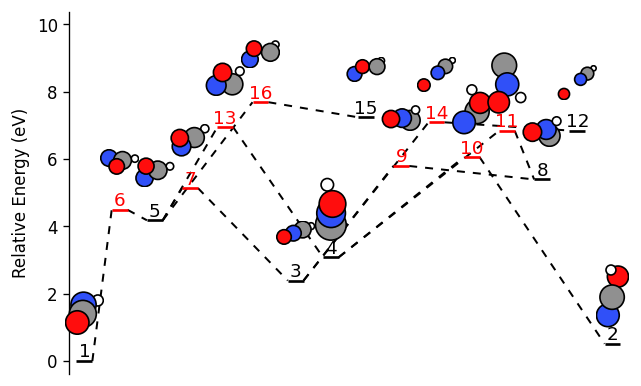

In [10]:
fig, ax = plt.subplots(dpi=120)
plot_energy_landscape(
    energy_landscape,
    ax=ax,
    layout="bfs",
    show_molecules=True,
    molecule_plot_backend="plot_molecule",
)
ax;

## Focus on a subset of states

In many practical situations the number of states in an energy landscape can become quite large, making the full network difficult to inspect in detail. Two useful ways to simplify the analysis are illustrated below.

The first option is `select_states`, which keeps only a user-defined list of states together with the corresponding links between them. This is useful when you already know which minima and transition states you want to compare.

The second option is `accessible_states`, which keeps the states that are accessible from a chosen starting state within a given energy window. This can be useful, for example, when you want to study which rearrangements are reachable from one intermediate under a limited thermal or activation-energy budget.

In both cases, `keep_original_ids=True` is very convenient because it preserves the state numbering from the original, more complicated landscape. This makes it easier to trace the selected states back to the full network and can also help when choosing a specific state as the starting point for a new AMS calculation aimed at exploring a different energy or configuration region of the system.


### `view` with a custom orientation in the `abc` basis

This cell selects a few states and applies a custom `ViewConfig` with an explicit normal and `normal_basis="abc"`. Even though we are visualizing molecules rather than periodic systems, this is still a valid basis choice here because it simply refers to the first, second, and third axes of the coordinate frame used by `view`. It shows how to control the `view` backend with a configuration object shared by all selected states.


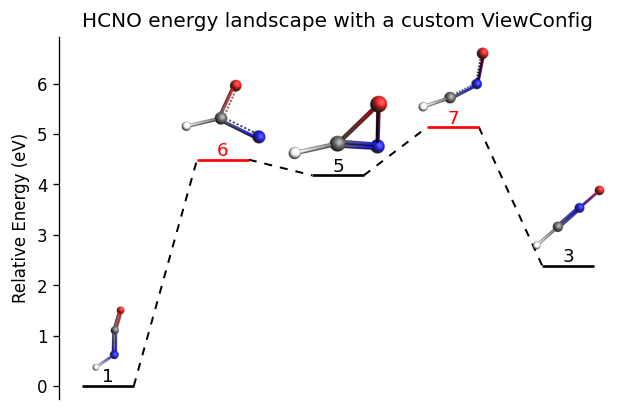

In [11]:
energy_landscape_filtered = energy_landscape.select_states([1, 6, 5, 7, 3], keep_original_ids=True)

conf = ViewConfig(
    normal=(0.0, 1.0, 0.0),
    normal_basis="abc",
    fixed_atom_size=False,
)

fig, ax = plt.subplots(dpi=120)
plot_energy_landscape(
    energy_landscape_filtered,
    ax=ax,
    show_molecules=True,
    molecule_scale=0.25,
    molecule_plot_backend="view",
    molecule_plot_kwargs={"config": conf},
)
ax.set_title("HCNO energy landscape with a custom ViewConfig")
ax;

### `view` with the ASE rendering backend

This cell keeps the `view` interface but switches its internal rendering backend to `ase_plot`. The point of this example is to show that the `view` backend can also be used in this way: it becomes closer in spirit to `molecule_plot_backend="plot_molecule"`, although it still relies on `ViewConfig` and therefore requires `view`-specific options instead of direct rotation strings.


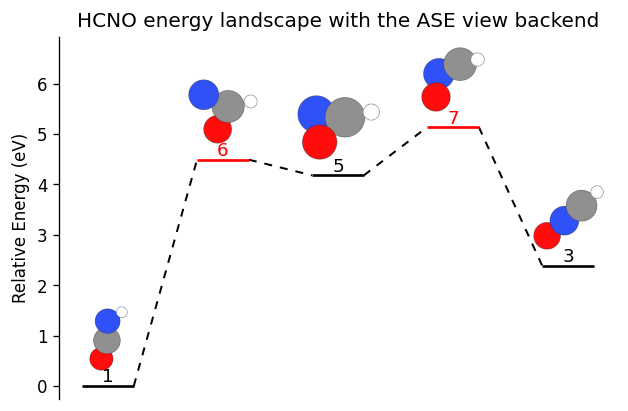

In [12]:
energy_landscape_filtered = energy_landscape.select_states([1, 6, 5, 7, 3], keep_original_ids=True)

conf = ViewConfig(
    normal=(0.0, 1.0, 0.0),
    normal_basis="xyz",
    fixed_atom_size=False,
)

fig, ax = plt.subplots(dpi=120)
plot_energy_landscape(
    energy_landscape_filtered,
    ax=ax,
    show_molecules=True,
    molecule_scale=0.25,
    molecule_plot_backend="view",
    molecule_plot_kwargs={"backend": "ase_plot", "config": conf},
)
ax.set_title("HCNO energy landscape with the ASE view backend")
ax;

### Accessible states around a reference state

This cell uses `accessible_states` to build a reduced landscape containing only the states that can be reached from state 3 within a chosen energy window. This type of analysis is useful when you want to focus on the locally reachable part of the network instead of the full landscape.


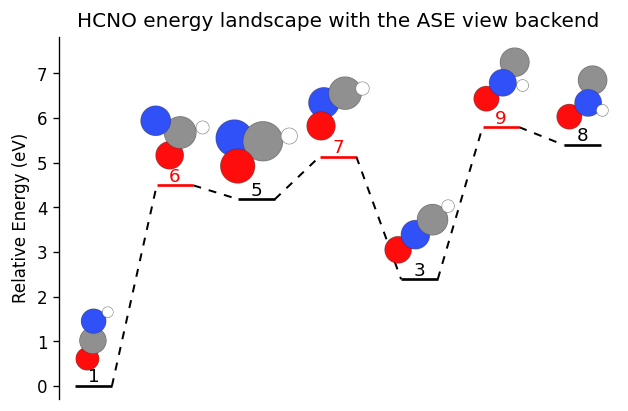

In [13]:
energy_landscape_filtered = energy_landscape.accessible_states(3, 3.5, unit="eV", keep_original_ids=True)

fig, ax = plt.subplots(dpi=120)
plot_energy_landscape(
    energy_landscape_filtered,
    ax=ax,
    show_molecules=True,
    molecule_scale=0.25,
    molecule_plot_backend="view",
    molecule_plot_kwargs={"backend": "ase_plot", "config": conf},
)
ax.set_title("HCNO energy landscape with the ASE view backend")
ax;

## Orient molecules with `plot_molecule`

The next two cells show how to use explicit `rotation` strings with `molecule_plot_backend="plot_molecule"`. This is the most direct option when you want camera-like rotations such as `"0x,0y,45z"`, because the orientation is controlled directly through Euler-like angles.


### One rotation for all selected states

This cell applies the same `plot_molecule` rotation to every molecule in the selected part of the landscape.


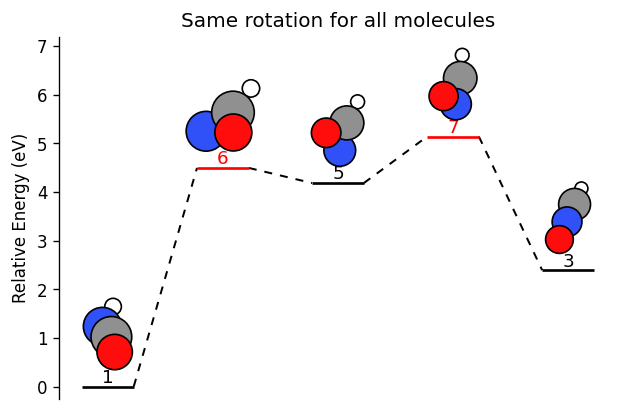

In [14]:
energy_landscape_filtered = energy_landscape.select_states([1, 6, 5, 7, 3], keep_original_ids=True)

fig, ax = plt.subplots(dpi=120)
plot_energy_landscape(
    energy_landscape_filtered,
    ax=ax,
    show_molecules=True,
    molecule_scale=0.30,
    molecule_plot_backend="plot_molecule",
    molecule_plot_kwargs={"rotation": "0x,0y,45z"},
)
ax.set_title("Same rotation for all molecules")
plt.show()

### Override the rotation for a few states

This cell keeps a common base rotation for all molecules and then overrides it for selected states through `molecule_plot_kwargs_by_state`. This is useful when only a few structures need a different viewpoint.


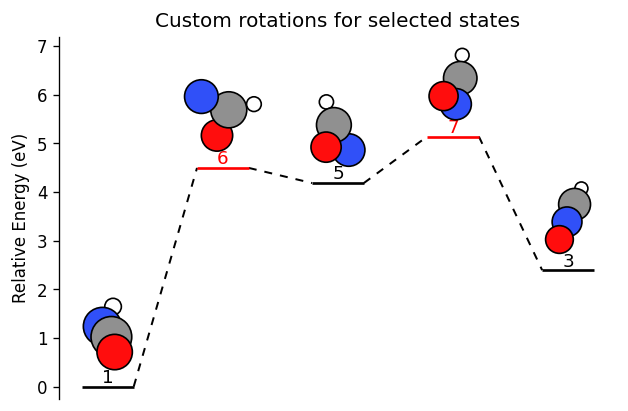

In [15]:
energy_landscape_filtered = energy_landscape.select_states([1, 6, 5, 7, 3], keep_original_ids=True)

fig, ax = plt.subplots(dpi=120)
plot_energy_landscape(
    energy_landscape_filtered,
    ax=ax,
    show_molecules=True,
    molecule_scale=0.30,
    molecule_plot_backend="plot_molecule",
    molecule_plot_kwargs={"rotation": "0x,0y,45z"},
    molecule_plot_kwargs_by_state={
        6: {"rotation": "90x,0y,0z"},
        5: {"rotation": "0x,0y,90z"},
    },
)
ax.set_title("Custom rotations for selected states")
ax;

## Orient molecules with `view`

The last two plotting examples show the same idea as above, but now using `molecule_plot_backend="view"`. In this case the orientation is controlled through `ViewConfig` objects rather than rotation strings: instead of specifying Euler-like angles, you specify the viewing direction or the normal to the view plane. This can be more natural when you want to reason in terms of views rather than manual rotations.


### One `ViewConfig` for all selected states

This cell passes a single `ViewConfig` to all selected states, giving every molecule the same `view` orientation.


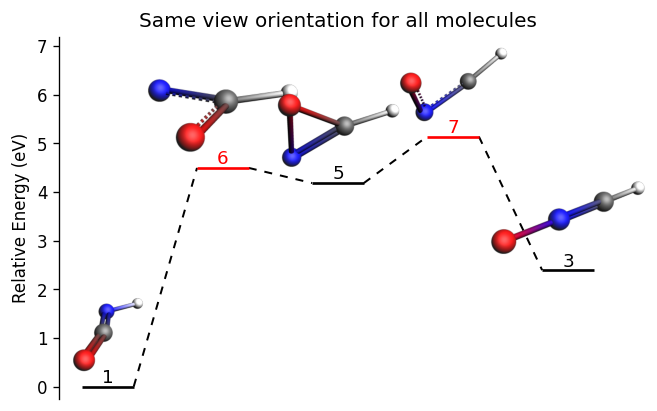

In [16]:
energy_landscape_filtered = energy_landscape.select_states([1, 6, 5, 7, 3], keep_original_ids=True)

conf_all = ViewConfig(
    normal=(0.0, 0.0, 1.0),
    normal_basis="xyz",
)

fig, ax = plt.subplots(dpi=120)
plot_energy_landscape(
    energy_landscape_filtered,
    ax=ax,
    show_molecules=True,
    molecule_scale=0.30,
    molecule_plot_backend="view",
    molecule_plot_kwargs={"config": conf_all},
)
ax.set_title("Same view orientation for all molecules")
plt.show()

### Override the `ViewConfig` for selected states

This cell starts from one common `ViewConfig` and then replaces it for a few states through `molecule_plot_kwargs_by_state`. This is the `view` analogue of the per-state rotation example shown above for `plot_molecule`.


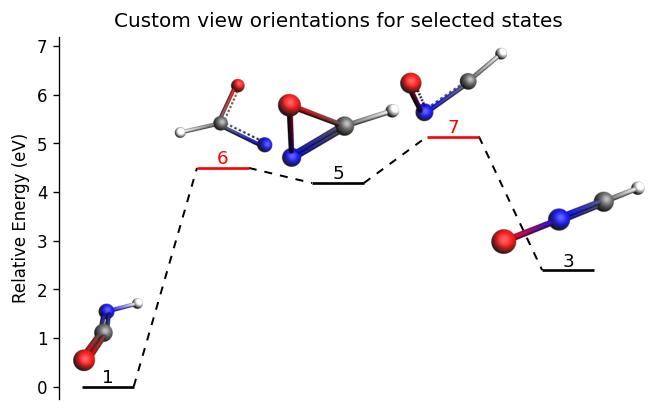

In [17]:
energy_landscape_filtered = energy_landscape.select_states([1, 6, 5, 7, 3], keep_original_ids=True)

conf_all = ViewConfig(
    normal=(0.0, 0.0, 1.0),
    normal_basis="xyz",
)
conf_state_6 = ViewConfig(
    normal=(0.0, 1.0, 0.0),
    normal_basis="xyz",
)
conf_state_5 = ViewConfig(
    normal=(0.0, 0.0, 1.0),
    normal_basis="xyz",
)

fig, ax = plt.subplots(dpi=120)
plot_energy_landscape(
    energy_landscape_filtered,
    ax=ax,
    show_molecules=True,
    molecule_scale=0.30,
    molecule_plot_backend="view",
    molecule_plot_kwargs={"config": conf_all},
    molecule_plot_kwargs_by_state={
        6: {"config": conf_state_6},
        5: {"config": conf_state_5},
    },
)
ax.set_title("Custom view orientations for selected states")
ax;

## Highlight selected states and links

This final example shows how to highlight a chosen subset of states directly in the energy landscape. The highlighting is drawn as a thick underlay behind the usual state and link lines, so the original appearance of the figure is preserved while the selected region is emphasized. When two highlighted states are connected, the corresponding link is highlighted as well. This can be useful for emphasizing a reaction path or a region of special interest inside a larger network.


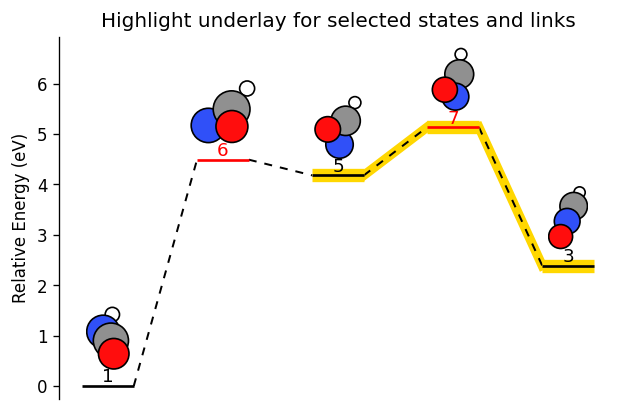

In [24]:
energy_landscape_filtered = energy_landscape.select_states([1, 6, 5, 7, 3], keep_original_ids=True)

fig, ax = plt.subplots(dpi=120)
plot_energy_landscape(
    energy_landscape_filtered,
    ax=ax,
    show_molecules=True,
    molecule_plot_backend="plot_molecule",
    molecule_plot_kwargs={"rotation": "0x,0y,45z"},
    highlight_states=[3, 5, 7],
    highlight_color="gold",
    highlight_linewidth=8.0,
)
ax.set_title("Highlight underlay for selected states and links")
ax;

## Summary

This notebook shows several complementary ways to inspect an AMS energy landscape: loading the landscape, comparing layouts, selecting subsets of states, visualizing molecules on top of the plot with either the `view` backend or the `plot_molecule` backend, and controlling the orientation globally or state by state.

The two molecule-plotting backends expose different controls: `plot_molecule` uses explicit Euler-like rotation strings, while `view` uses a view-oriented description through `ViewConfig`. In addition, the `view` backend can also use `ase_plot` internally, which provides a route closer to `plot_molecule` while still using `view`-style options.

Finally, the highlighting option can be used to emphasize selected states and the links between them without changing the overall style of the figure, which is useful for drawing attention to a particular reaction path or region of interest in a larger landscape.
